In [3]:
library("Seurat")
library("ggplot2")
library("PaaSc")
library("ROCit")

Loading required package: SeuratObject

Loading required package: sp

Warning message:
“package ‘sp’ was built under R version 4.2.3”

Attaching package: ‘SeuratObject’


The following objects are masked from ‘package:base’:

    intersect, t


Warning message:
“package ‘ggplot2’ was built under R version 4.2.3”
Warning message:
“replacing previous import ‘data.table::shift’ by ‘tictoc::shift’ when loading ‘CelliD’”


## Data preparation
We use the pbmc3k data from SeuratData. See [pbmc3k_tutorial](https://satijalab.org/seurat/articles/pbmc3k_tutorial). We also provide the raw data in the [github](https://github.com/yoyoong/PaaSc/tree/1.0.0/data).

In [4]:
setwd("/sibcb1/bioinformatics/hongyuyang/code/PaaSc")
data <- Read10X(data.dir = "./data/pbmc3k/")
object <- CreateSeuratObject(counts = data, min.cells = 3, min.features = 200)

Warning message:
“Feature names cannot have underscores ('_'), replacing with dashes ('-')”


## Compute single-cell pathway activity score
The backfround gene sets is downloaded from [KEGG_LEGACY subset of CP](https://www.gsea-msigdb.org/gsea/msigdb/download_file.jsp?filePath=/msigdb/release/2024.1.Hs/c2.cp.kegg_legacy.v2024.1.Hs.symbols.gmt) in [MSigDB](https://www.gsea-msigdb.org/). The target pathway is B_cell_activation from ...

In [5]:
# Step1: Compute MCA loading and embedding
object <- computeMCA(object, nmcs = 20)

Normalizing layer: counts

Computing Fuzzy Matrix



1.563 sec elapsed


Computing SVD



2.768 sec elapsed


Computing Coordinates



0.271 sec elapsed


In [6]:
# Step2: Get gene occurrence rate in background and signature genesets
background_geneset <- "./data/kegg_legacy.gmt"
B_cell_activation <- readLines("./data/B_cell_activation.txt")
pathway_geneset <- list(B_cell_activation = B_cell_activation)
gene_rate <- getGeneRate(background.geneset = background_geneset, pathway.geneset = pathway_geneset)
head(gene_rate)

,background,B_cell_activation
,<dbl>,<dbl>
ABCA1,0.005347594,0
ABCA10,0.005347594,0
ABCA12,0.005347594,0
ABCA13,0.005347594,0
ABCA2,0.010695187,0
ABCA3,0.005347594,0


In [7]:
# Step3: Do regression of gene loading (Y) and gene rate (X)
regression_data <- doRegression(object, gene.rate = gene_rate)
head(regression_data)

,mca_1,mca_2,mca_3,mca_4,mca_5,mca_6,mca_7,mca_8,mca_9,mca_10,mca_11,mca_12,mca_13,mca_14,mca_15,mca_16,mca_17,mca_18,mca_19,mca_20
B_cell_activation.t,1.4771041,0.06744623,-3.27673294,-4.948416e+00,-2.648875008,-1.4464791,-1.56746433,-0.5044654,-0.4973121,-0.89676884,-1.1162053,-0.6161117,0.6996178,-0.4407662,-0.9487692,0.03476422,-0.8899237,0.9950947,0.6624272,0.3557867
B_cell_activation.background.t,0.3260923,0.47468205,-0.01239580,6.320301e-01,-0.971835309,-0.2691793,-0.03343365,0.2556559,0.5271550,0.06713614,-1.5056340,-0.5075712,-0.3743437,-0.8153361,0.6287907,0.22038331,0.6308422,-1.3941646,-1.2392238,0.6510335
B_cell_activation.pvalue,0.1397424,0.94623052,0.00106094,7.853507e-07,0.008114199,0.1481371,0.11710133,0.6139678,0.6190018,0.36990718,0.2644149,0.5378630,0.4842150,0.6594109,0.3428070,0.97226984,0.3735712,0.3197626,0.5077434,0.7220229
B_cell_activation.background.pvalue,0.7443751,0.63504478,0.99011058,5.274106e-01,0.331203156,0.7878084,0.97333078,0.7982323,0.5981211,0.94647736,0.1322561,0.6117878,0.7081725,0.4149383,0.5295293,0.82558617,0.5281871,0.1633610,0.2153501,0.5150698


In [8]:
# Step4: Compute the pathway activity score
score_data <- computeScore(object, regression.data = regression_data, weight = FALSE, normalize = "z-score")
head(score_data)

,B_cell_activation
,<dbl>
AAACATACAACCAC-1,-0.34335603
AAACATTGAGCTAC-1,2.10602310
AAACATTGATCAGC-1,-1.09800230
AAACCGTGCTTCCG-1,0.04420805
AAACCGTGTATGCG-1,0.22933962
AAACGCACTGGTAC-1,-0.24219294


Warning message:
“The default method for RunUMAP has changed from calling Python UMAP via reticulate to the R-native UWOT using the cosine metric
To use Python UMAP via reticulate, set umap.method to 'umap-learn' and metric to 'correlation'
This message will be shown once per session”
Found more than one class "dist" in cache; using the first, from namespace 'spam'

Also defined by ‘BiocGenerics’

Found more than one class "dist" in cache; using the first, from namespace 'spam'

Also defined by ‘BiocGenerics’



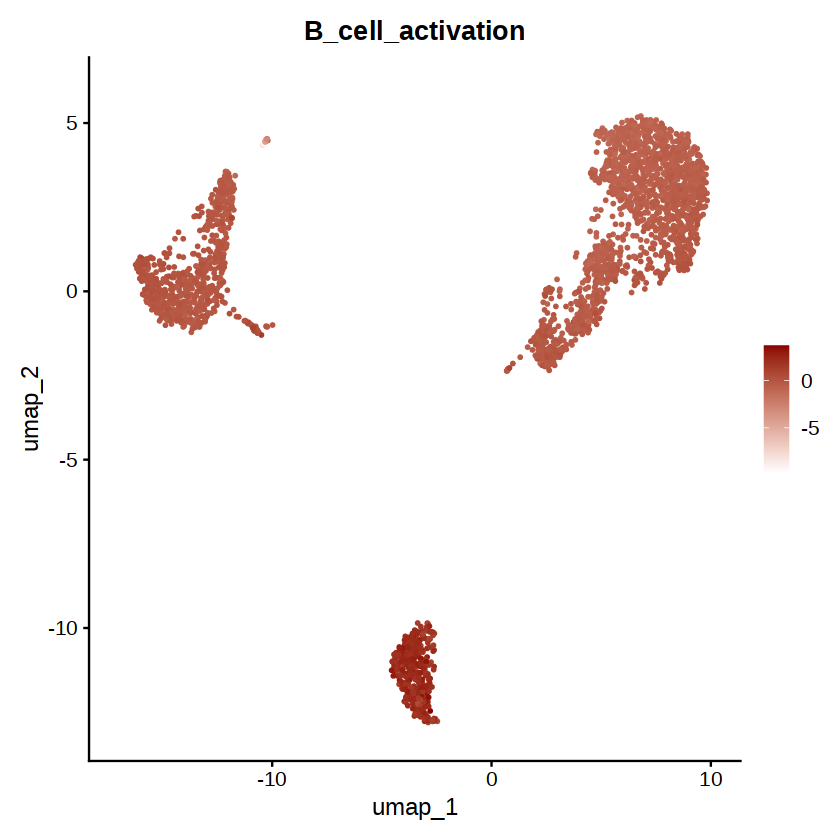

In [9]:
# Visual the pathway activity score through UMAP reduction
object <- FindVariableFeatures(object, verbose = FALSE)
object <- ScaleData(object, verbose = FALSE)
object <- RunPCA(object, verbose = FALSE)
object <- FindNeighbors(object, verbose = FALSE)
object <- RunUMAP(object, dims = 1:20, verbose = FALSE)
object@meta.data$B_cell_activation <- score_data[colnames(object), ]
FeaturePlot(object, features = "B_cell_activation", cols = c('white', 'darkred')) 

## Binarization and label the cell
Binarize score data into two normal distributions using Gaussian mixture model. The average of two normal distributions' mean used as the threshold to divide into positive and negative classes.

In [10]:
# Step5：Do binarization and get the cell label
label_data <- doBinarization(score_data, n.cluster = 2, method = "GMM")
head(label_data)

number of iterations= 10 


,B_cell_activation.label
,"<chr[,1]>"
AAACATACAACCAC-1,negative
AAACATTGAGCTAC-1,positive
AAACATTGATCAGC-1,negative
AAACCGTGCTTCCG-1,negative
AAACCGTGTATGCG-1,negative
AAACGCACTGGTAC-1,negative


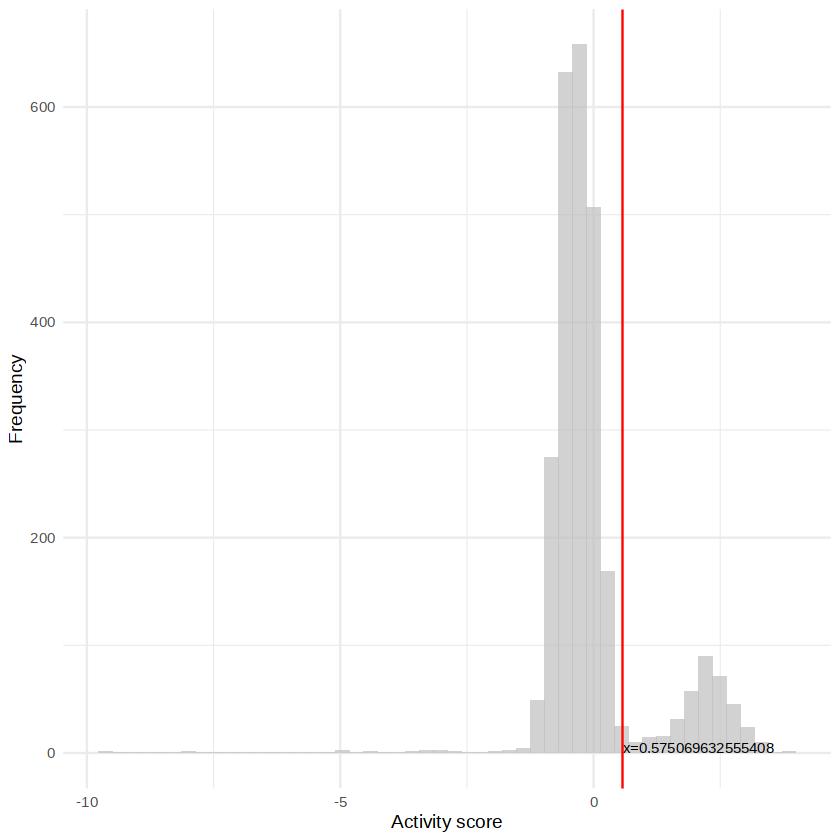

In [11]:
threshold <- min(score_data[rownames(label_data[label_data['B_cell_activation.label'] == 'positive', ]), 'B_cell_activation'])
ggplot(score_data, aes(x = B_cell_activation)) +
  geom_histogram(bins = 50, fill = "grey", alpha = 0.7) + 
  geom_vline(xintercept = threshold, color = "red", linetype = "solid") +
  annotate("text", x = threshold, y = 0, label = paste0("x=", threshold), hjust = 0, vjust = 0, color = "black", size = 3) + 
  xlab("Activity score") + ylab("Frequency") + theme_minimal()

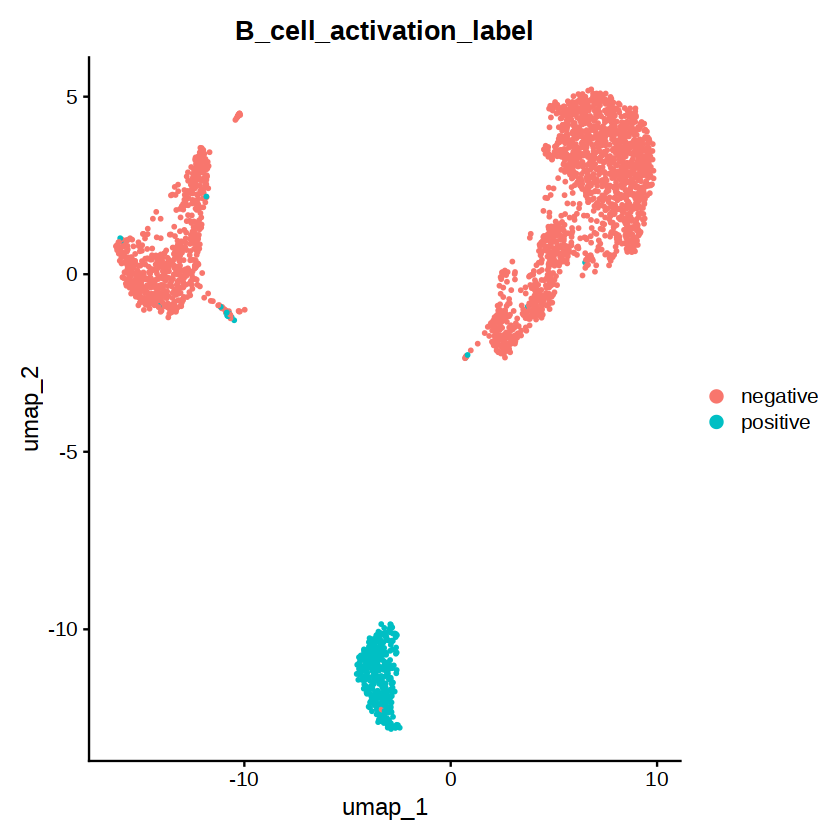

In [12]:
# Visual the cell label
object@meta.data$B_cell_activation_label <- label_data[colnames(object), ]
DimPlot(object, group.by = "B_cell_activation_label")

## Analysis the classification accuracy
Using pre-annotated cell type information, calculate the AUC-ROC value of B cells annotated using binarization.

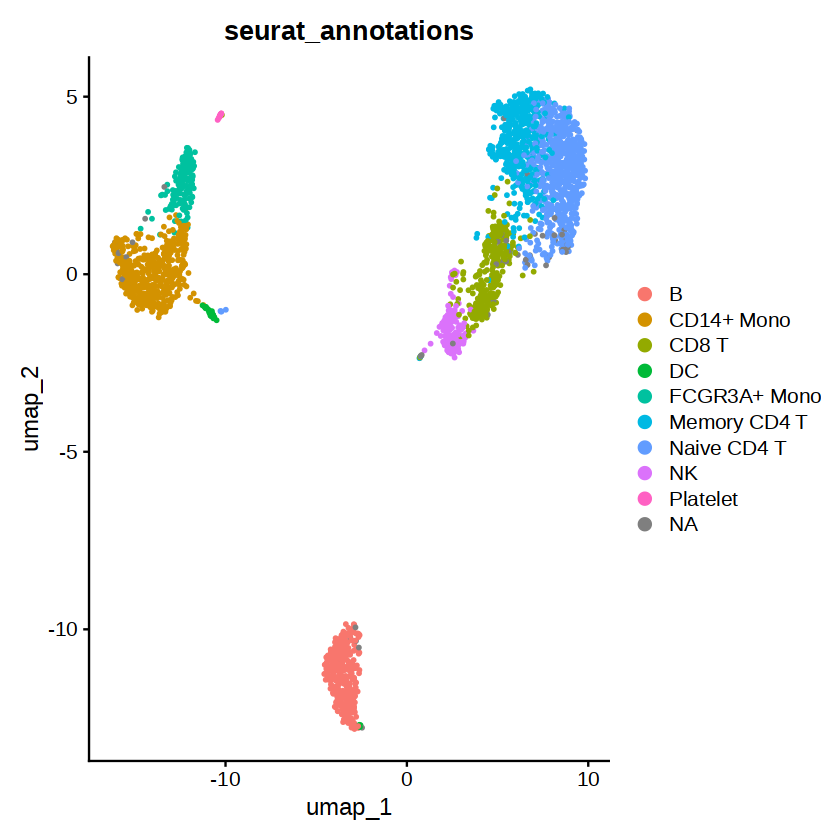

In [13]:
annotation_file <- "./data/pbmc3k_seurat_annotation.txt"
seurat_annotations <- read.table(annotation_file, header = TRUE, row.names = 1, sep = "\t")

# Plot the pre-annotated celltype in UMAP
object@meta.data$seurat_annotations <- seurat_annotations[colnames(object), ]
DimPlot(object, group.by = "seurat_annotations")

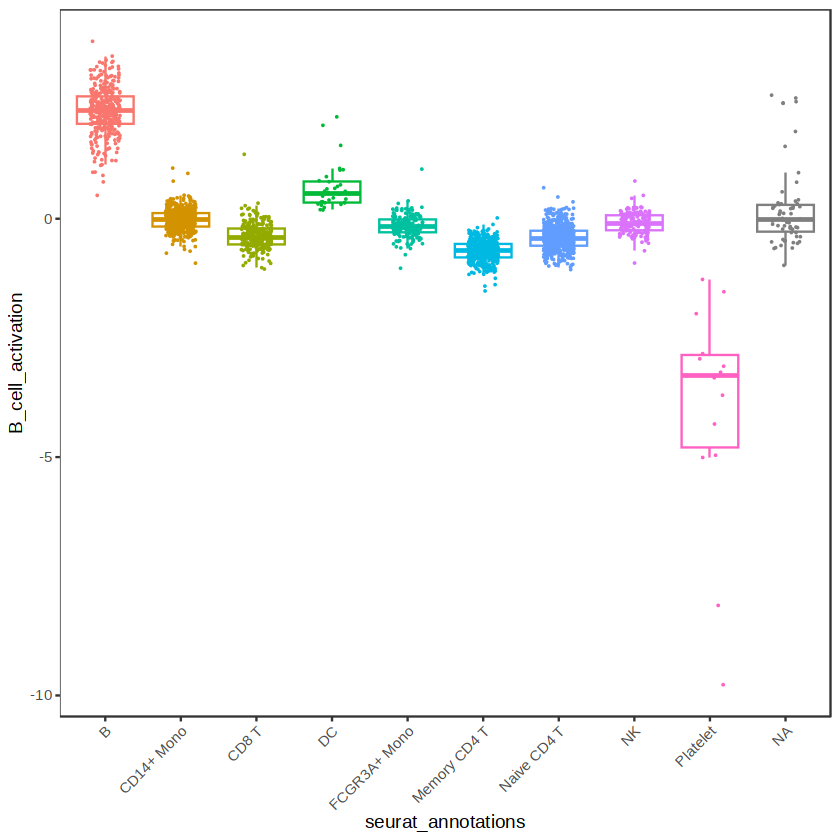

In [14]:
# Plot the B_cell_activation activity score in all celltypes through pre-annotated information
score_data_withanno <- cbind(score_data, seurat_annotations)
ggplot(score_data_withanno, aes(x = seurat_annotations, y = B_cell_activation, color = seurat_annotations)) + 
    geom_boxplot(outlier.shape = NA) + geom_jitter(width = 0.2, size = 0.01) + theme_bw() + 
    theme(panel.grid.major = element_blank(), panel.grid.minor = element_blank()) + 
    theme(plot.title = element_text(hjust = 0.5)) + theme(legend.title=element_blank()) + 
    theme(legend.position="none") +  theme(axis.text.x = element_text(vjust = 1, hjust = 1, angle = 45))

                            
 Method used: empirical     
 Number of positive(s): 344 
 Number of negative(s): 2356
 Area under curve: 0.998    


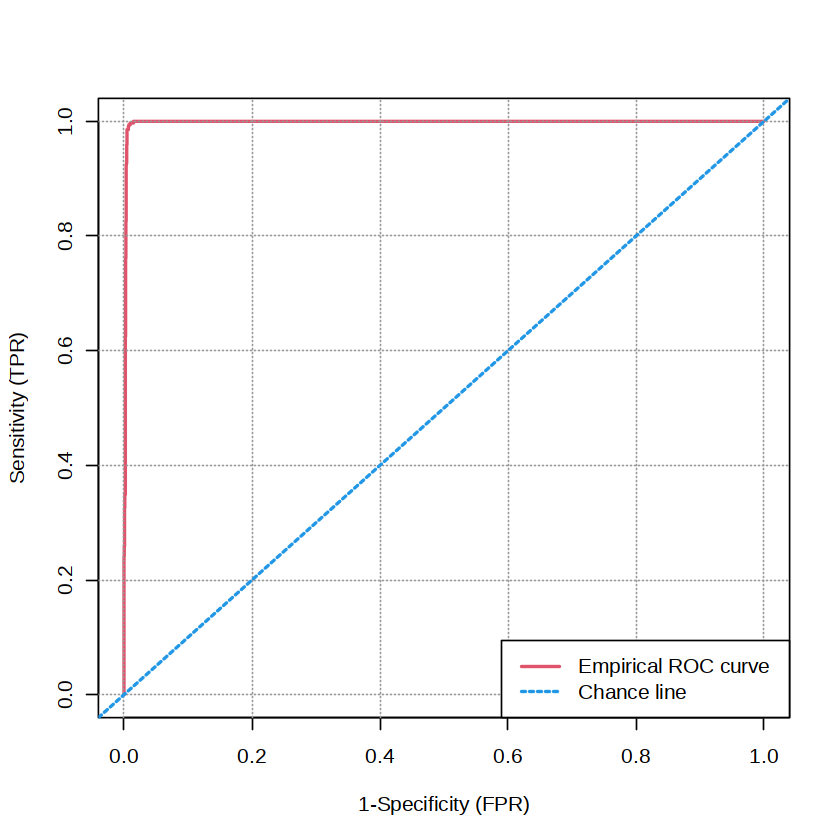

In [15]:
# Calculate the B cell classification AUC-ROC value
label <- rep('others', nrow(score_data_withanno))
label[score_data_withanno$seurat_annotations == "B"] <- "B"
roc_empirical <- rocit(score = score_data_withanno$B_cell_activation, class = label, negref = "others")
title <- paste0('AUC:', strsplit(as.character(summary(roc_empirical)[4,]), ':')[[1]][2])
plot(roc_empirical, YIndex = F, values = F, col = c(2,4), main = title)